In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('ecommerce_orders.csv')
df

,order_id,customer_id,order_date,city,product_category,price,quantity,discount_percent,payment_method,order_status,customer_rating
0,ORD10000,CUST1654,2024-11-01,Surat,Electronics,1935.25,4,10.0,Credit Card,Shipped,2.0
1,ORD10001,CUST1114,2024-01-02,Hyderabad,Beauty,NaN,3,0.0,UPI,Delivered,4.0
2,ORD10002,CUST1025,2024-05-21,Bangalore,Clothing,3686.77,3,20.0,Credit Card,Cancelled,1.0
3,ORD10003,CUST1759,2024-03-15,Bangalore,Electronics,3033.43,3,NaN,Net Banking,Returned,2.0
4,ORD10004,CUST1281,2024-03-07,Hyderabad,Home,864.49,4,10.0,Cash on Delivery,Delivered,5.0
...,...,...,...,...,...,...,...,...,...,...,...
1995,ORD11995,CUST1238,2024-02-28,Bangalore,Sports,3319.08,4,10.0,UPI,Delivered,4.0
1996,ORD11996,CUST1336,2024-06-27,Mumbai,Clothing,4787.41,3,5.0,Net Banking,Cancelled,5.0
1997,ORD11997,CUST1792,2024-06-29,Bangalore,Beauty,437.89,2,10.0,Net Banking,Delivered,2.0
1998,ORD11998,CUST1151,2024-08-22,NaN,Beauty,379.57,4,15.0,Net Banking,Shipped,5.0


# EDA - Exploratory Data Analysis

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   str    
 1   customer_id       2000 non-null   str    
 2   order_date        2000 non-null   str    
 3   city              1960 non-null   str    
 4   product_category  2000 non-null   str    
 5   price             1970 non-null   float64
 6   quantity          2000 non-null   int64  
 7   discount_percent  1647 non-null   float64
 8   payment_method    2000 non-null   str    
 9   order_status      2000 non-null   str    
 10  customer_rating   1672 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 172.0 KB


In [40]:
df.describe()

,price,quantity,discount_percent,customer_rating
count,1970.000000,2000.000000,1647.000000,1672.000000
mean,2540.107838,2.499500,10.157863,2.995215
std,1430.490379,1.135625,7.004553,1.425585
min,115.770000,1.000000,0.000000,1.000000
25%,1265.090000,1.000000,5.000000,2.000000
50%,2578.765000,3.000000,10.000000,3.000000
75%,3771.585000,4.000000,15.000000,4.000000
max,4998.620000,4.000000,20.000000,5.000000


In [41]:
df.head()

,order_id,customer_id,order_date,city,product_category,price,quantity,discount_percent,payment_method,order_status,customer_rating
0,ORD10000,CUST1654,2024-11-01,Surat,Electronics,1935.25,4,10.0,Credit Card,Shipped,2.0
1,ORD10001,CUST1114,2024-01-02,Hyderabad,Beauty,NaN,3,0.0,UPI,Delivered,4.0
2,ORD10002,CUST1025,2024-05-21,Bangalore,Clothing,3686.77,3,20.0,Credit Card,Cancelled,1.0
3,ORD10003,CUST1759,2024-03-15,Bangalore,Electronics,3033.43,3,NaN,Net Banking,Returned,2.0
4,ORD10004,CUST1281,2024-03-07,Hyderabad,Home,864.49,4,10.0,Cash on Delivery,Delivered,5.0


In [42]:
df.tail()

,order_id,customer_id,order_date,city,product_category,price,quantity,discount_percent,payment_method,order_status,customer_rating
1995,ORD11995,CUST1238,2024-02-28,Bangalore,Sports,3319.08,4,10.0,UPI,Delivered,4.0
1996,ORD11996,CUST1336,2024-06-27,Mumbai,Clothing,4787.41,3,5.0,Net Banking,Cancelled,5.0
1997,ORD11997,CUST1792,2024-06-29,Bangalore,Beauty,437.89,2,10.0,Net Banking,Delivered,2.0
1998,ORD11998,CUST1151,2024-08-22,NaN,Beauty,379.57,4,15.0,Net Banking,Shipped,5.0
1999,ORD11999,CUST1807,2024-11-12,Ahmedabad,Clothing,1482.72,2,10.0,Debit Card,Returned,1.0


In [43]:
df.isnull().sum()

order_id              0
customer_id           0
order_date            0
city                 40
product_category      0
price                30
quantity              0
discount_percent    353
payment_method        0
order_status          0
customer_rating     328
dtype: int64

In [44]:
df.shape

(2000, 11)

In [45]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'city', 'product_category',
       'price', 'quantity', 'discount_percent', 'payment_method',
       'order_status', 'customer_rating'],
      dtype='str')

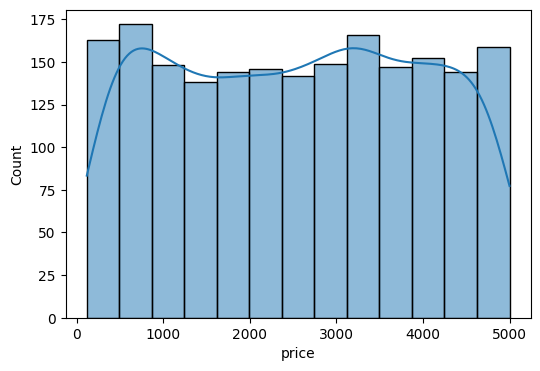

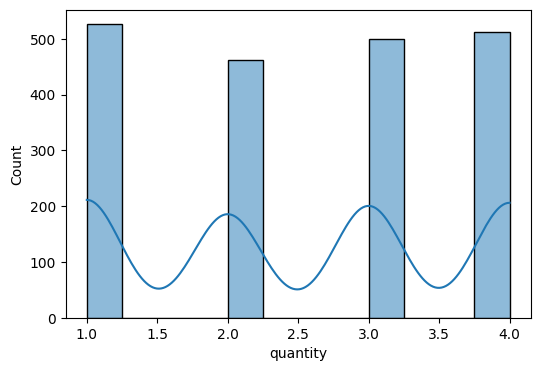

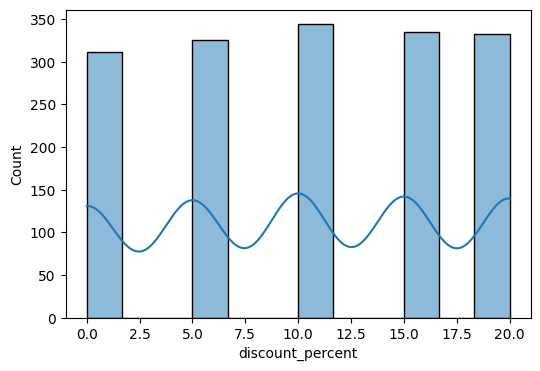

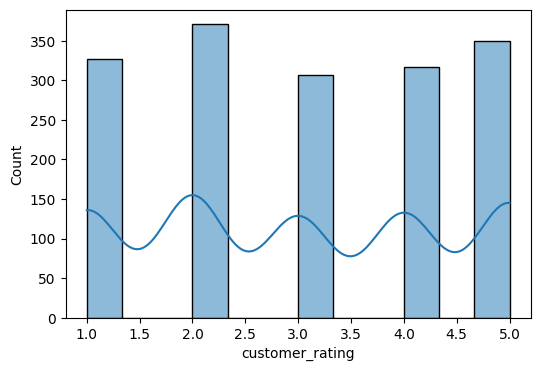

In [46]:
numeric_columns = [ 'price', 'quantity', 'discount_percent', 'customer_rating']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

<Axes: xlabel='count', ylabel='city'>

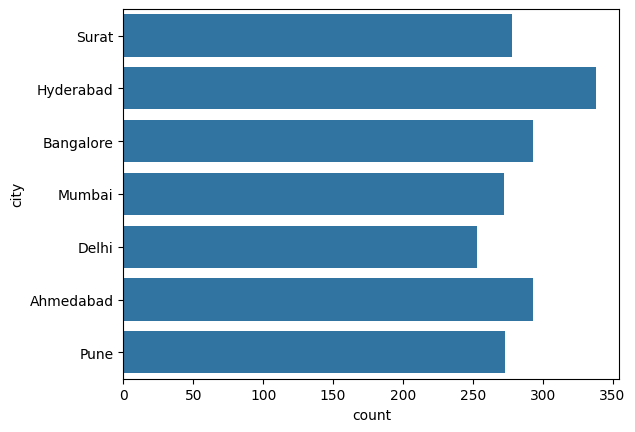

In [64]:
sns.countplot(y = df['city'])

<Axes: xlabel='product_category', ylabel='count'>

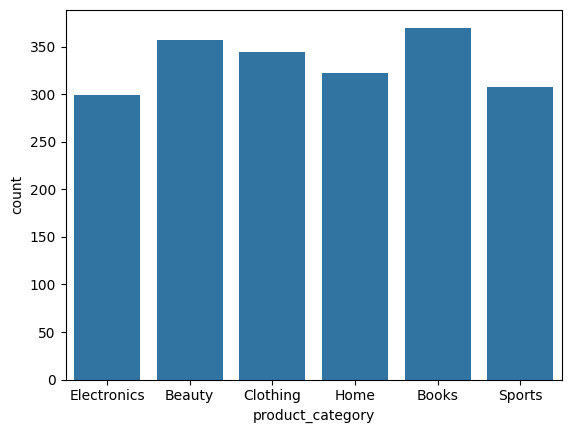

In [48]:
sns.countplot(x = df['product_category'])

<Axes: xlabel='count', ylabel='payment_method'>

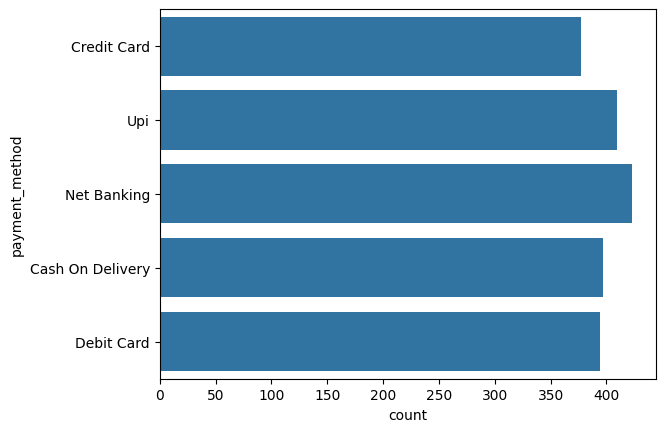

In [65]:
sns.countplot(y = df['payment_method'])

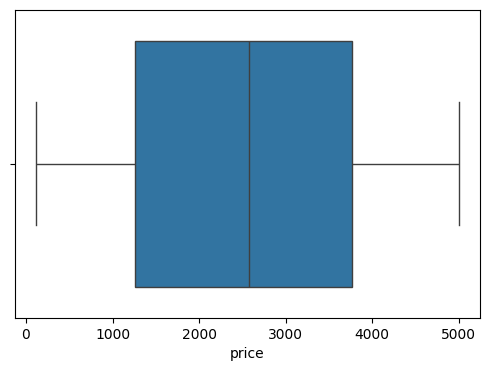

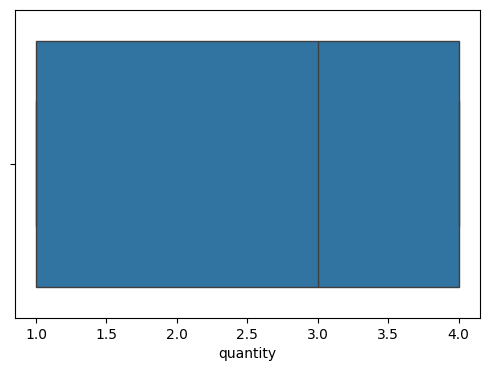

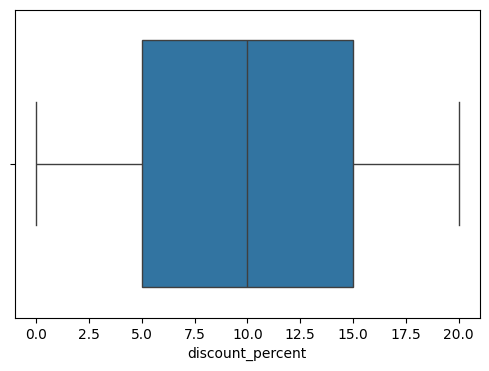

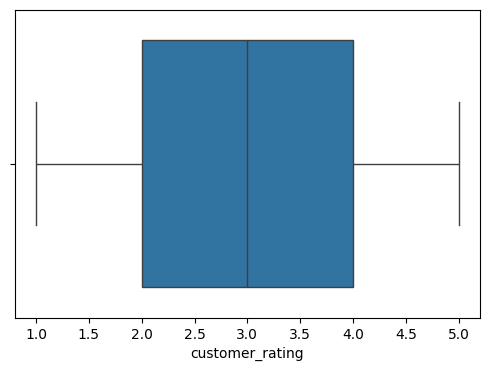

In [50]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

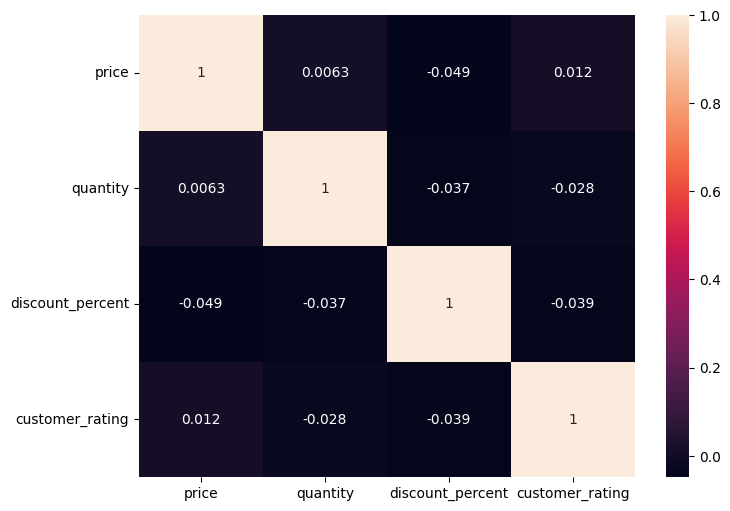

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   str    
 1   customer_id       2000 non-null   str    
 2   order_date        2000 non-null   str    
 3   city              1960 non-null   str    
 4   product_category  2000 non-null   str    
 5   price             1970 non-null   float64
 6   quantity          2000 non-null   int64  
 7   discount_percent  1647 non-null   float64
 8   payment_method    2000 non-null   str    
 9   order_status      2000 non-null   str    
 10  customer_rating   1672 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 172.0 KB


In [53]:
df.isnull().sum()

order_id              0
customer_id           0
order_date            0
city                 40
product_category      0
price                30
quantity              0
discount_percent    353
payment_method        0
order_status          0
customer_rating     328
dtype: int64

In [54]:
# fill empty or null city with mode of city (hyderabad)
print(df['city'].mode()[0])
df['city'] = df['city'].fillna(df['city'].mode()[0])
df.isnull().sum()

Hyderabad


order_id              0
customer_id           0
order_date            0
city                  0
product_category      0
price                30
quantity              0
discount_percent    353
payment_method        0
order_status          0
customer_rating     328
dtype: int64

In [55]:
# fill empty or null price with mean of price
print(df['price'].mean())
df['price'] = df['price'].fillna(df['price'].mean())
df.isnull().sum()

2540.1078375634515


order_id              0
customer_id           0
order_date            0
city                  0
product_category      0
price                 0
quantity              0
discount_percent    353
payment_method        0
order_status          0
customer_rating     328
dtype: int64

In [56]:
# fill empty or null discount_percent with mean of discount_percent
print(df['discount_percent'].mean())
df['discount_percent'] = df['discount_percent'].fillna(df['discount_percent'].mean())
df.isnull().sum()

10.1578627808136


order_id              0
customer_id           0
order_date            0
city                  0
product_category      0
price                 0
quantity              0
discount_percent      0
payment_method        0
order_status          0
customer_rating     328
dtype: int64

In [57]:
# fill empty or null customer_rating with mean of customer_rating
print(df['customer_rating'].mean())
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].mean())
df.isnull().sum()

2.9952153110047846


order_id            0
customer_id         0
order_date          0
city                0
product_category    0
price               0
quantity            0
discount_percent    0
payment_method      0
order_status        0
customer_rating     0
dtype: int64

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   str    
 1   customer_id       2000 non-null   str    
 2   order_date        2000 non-null   str    
 3   city              2000 non-null   str    
 4   product_category  2000 non-null   str    
 5   price             2000 non-null   float64
 6   quantity          2000 non-null   int64  
 7   discount_percent  2000 non-null   float64
 8   payment_method    2000 non-null   str    
 9   order_status      2000 non-null   str    
 10  customer_rating   2000 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 172.0 KB


In [ ]:
# convert date from string to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.dayofweek

In [60]:
df.head()

,order_id,customer_id,order_date,city,product_category,price,quantity,discount_percent,payment_method,order_status,customer_rating,order_month,day_of_week
0,ORD10000,CUST1654,2024-11-01,Surat,Electronics,1935.250000,4,10.000000,Credit Card,Shipped,2.0,11,4
1,ORD10001,CUST1114,2024-01-02,Hyderabad,Beauty,2540.107838,3,0.000000,UPI,Delivered,4.0,1,1
2,ORD10002,CUST1025,2024-05-21,Bangalore,Clothing,3686.770000,3,20.000000,Credit Card,Cancelled,1.0,5,1
3,ORD10003,CUST1759,2024-03-15,Bangalore,Electronics,3033.430000,3,10.157863,Net Banking,Returned,2.0,3,4
4,ORD10004,CUST1281,2024-03-07,Hyderabad,Home,864.490000,4,10.000000,Cash on Delivery,Delivered,5.0,3,3


In [62]:
# standardizing strings
df['city'] = df['city'].str.strip().str.title()
df['product_category'] = df['product_category'].str.strip().str.title()
df['payment_method'] = df['payment_method'].str.strip().str.title()
df['order_status'] = df['order_status'].str.strip().str.title()

In [63]:
df.head()

,order_id,customer_id,order_date,city,product_category,price,quantity,discount_percent,payment_method,order_status,customer_rating,order_month,day_of_week
0,ORD10000,CUST1654,2024-11-01,Surat,Electronics,1935.250000,4,10.000000,Credit Card,Shipped,2.0,11,4
1,ORD10001,CUST1114,2024-01-02,Hyderabad,Beauty,2540.107838,3,0.000000,Upi,Delivered,4.0,1,1
2,ORD10002,CUST1025,2024-05-21,Bangalore,Clothing,3686.770000,3,20.000000,Credit Card,Cancelled,1.0,5,1
3,ORD10003,CUST1759,2024-03-15,Bangalore,Electronics,3033.430000,3,10.157863,Net Banking,Returned,2.0,3,4
4,ORD10004,CUST1281,2024-03-07,Hyderabad,Home,864.490000,4,10.000000,Cash On Delivery,Delivered,5.0,3,3


In [66]:
# encoding categorical variables
df = pd.get_dummies(df, columns=['city','product_category','payment_method'])

status_map = { 'Cancelled': 0, 'Returned': 1, 'Shipped': 2, 'Delivered': 3 }
df['order_status_rank'] = df['order_status'].map(status_map)

In [67]:
df.head()

,order_id,customer_id,order_date,price,quantity,discount_percent,order_status,customer_rating,order_month,day_of_week,...,product_category_Clothing,product_category_Electronics,product_category_Home,product_category_Sports,payment_method_Cash On Delivery,payment_method_Credit Card,payment_method_Debit Card,payment_method_Net Banking,payment_method_Upi,order_status_rank
0,ORD10000,CUST1654,2024-11-01,1935.250000,4,10.000000,Shipped,2.0,11,4,...,False,True,False,False,False,True,False,False,False,2
1,ORD10001,CUST1114,2024-01-02,2540.107838,3,0.000000,Delivered,4.0,1,1,...,False,False,False,False,False,False,False,False,True,3
2,ORD10002,CUST1025,2024-05-21,3686.770000,3,20.000000,Cancelled,1.0,5,1,...,True,False,False,False,False,True,False,False,False,0
3,ORD10003,CUST1759,2024-03-15,3033.430000,3,10.157863,Returned,2.0,3,4,...,False,True,False,False,False,False,False,True,False,1
4,ORD10004,CUST1281,2024-03-07,864.490000,4,10.000000,Delivered,5.0,3,3,...,False,False,True,False,True,False,False,False,False,3


In [69]:
# Check for duplicate values
df.duplicated().sum()
# drop duplicate rows if there
# df.drop_duplicates(inplace=True)

np.int64(0)

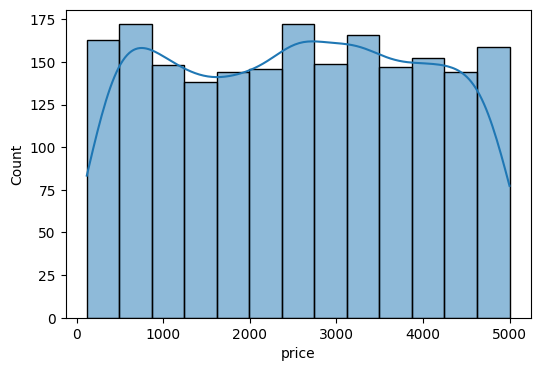

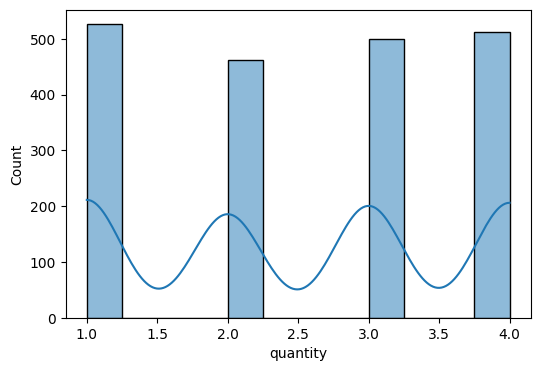

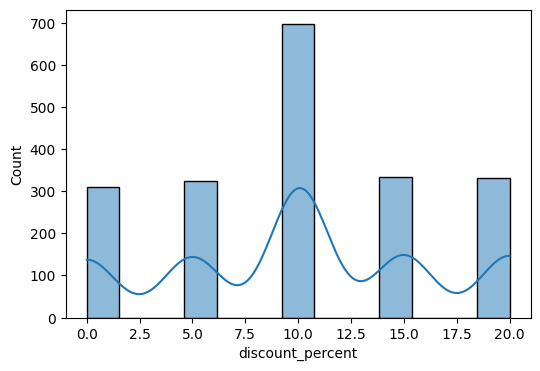

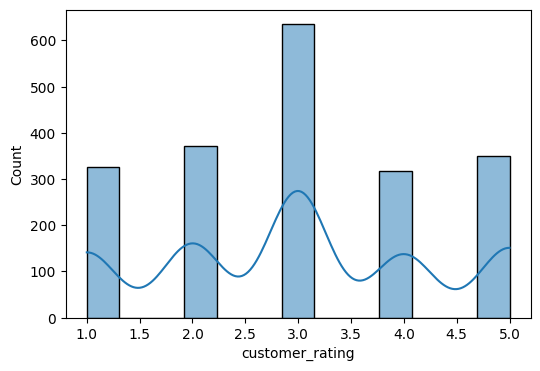

In [72]:
for i in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i], kde=True)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   order_id                         2000 non-null   str           
 1   customer_id                      2000 non-null   str           
 2   order_date                       2000 non-null   datetime64[us]
 3   price                            2000 non-null   float64       
 4   quantity                         2000 non-null   int64         
 5   discount_percent                 2000 non-null   float64       
 6   order_status                     2000 non-null   str           
 7   customer_rating                  2000 non-null   float64       
 8   order_month                      2000 non-null   int32         
 9   day_of_week                      2000 non-null   int32         
 10  city_Ahmedabad                   2000 non-null   bool          
 11  ci

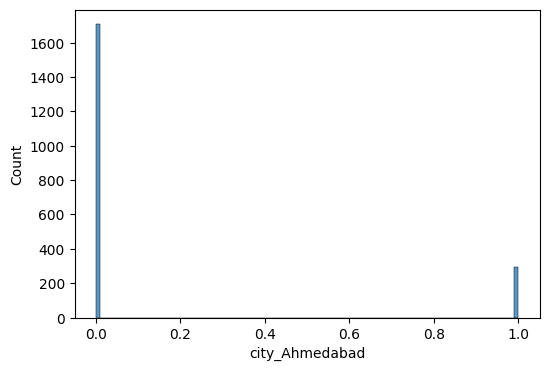

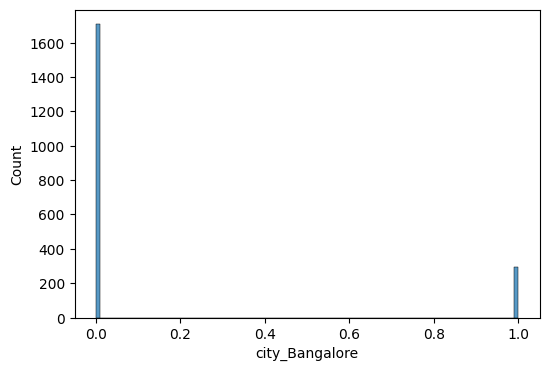

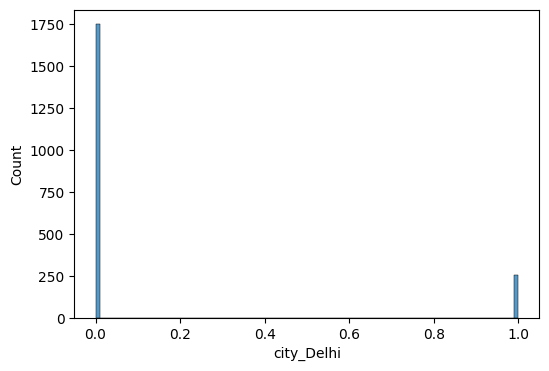

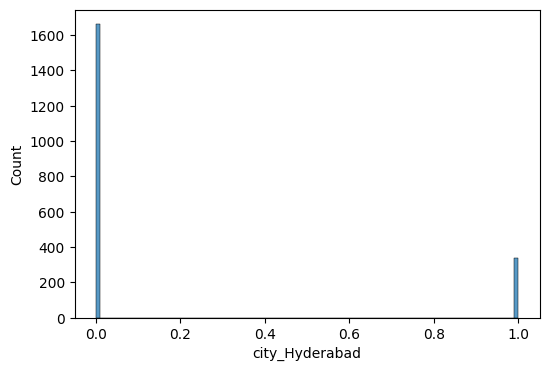

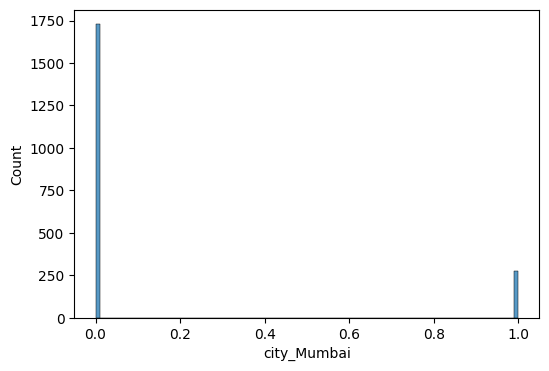

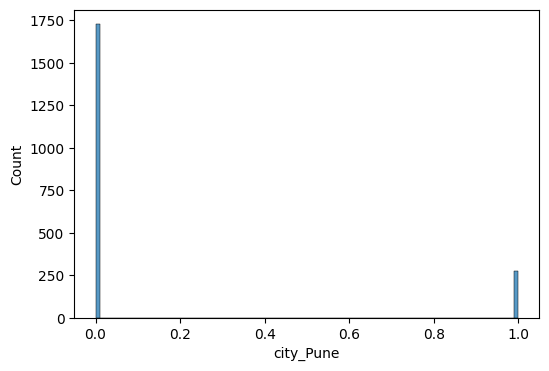

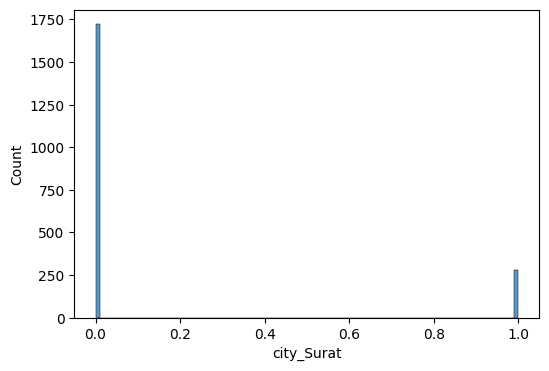

In [ ]:
cities = ['city_Ahmedabad','city_Bangalore','city_Delhi','city_Hyderabad','city_Mumbai','city_Pune','city_Surat']
for col in cities:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df[col])